<a href="https://colab.research.google.com/github/sjkim25/Introduction-to-Artificial-Intelligence/blob/main/week4/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/titanic.csv

In [250]:
import pandas as pd
import numpy as np

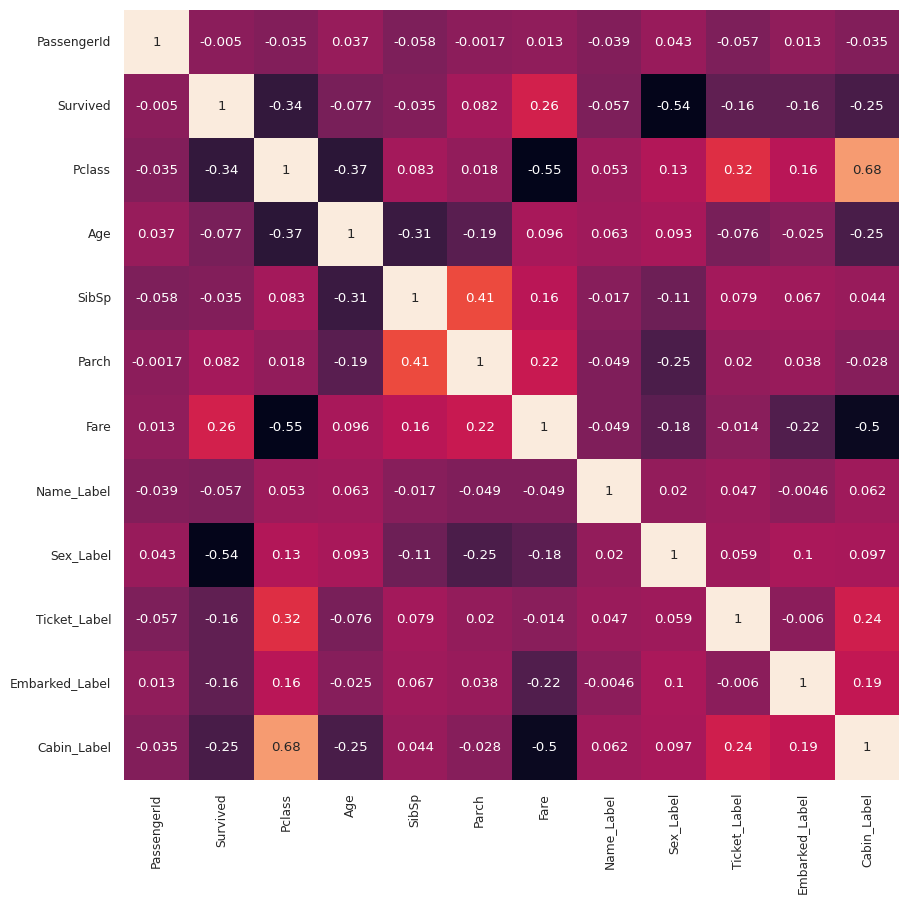

In [313]:
# Core Relation 측정
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")

# String data들을 Float으로 변환
le_name = LabelEncoder()
df['Name_Label'] = le_name.fit_transform(df['Name'])

le_sex = LabelEncoder()
df['Sex_Label'] = le_sex.fit_transform(df['Sex'])

le_tic = LabelEncoder()
df['Ticket_Label'] = le_tic.fit_transform(df['Ticket'])

le_emb = LabelEncoder()
df['Embarked_Label'] = le_emb.fit_transform(df['Embarked'])

le_cab = LabelEncoder()
df['Cabin_Label'] = le_cab.fit_transform(df['Cabin'])

df.drop('Name', axis=1, inplace=True)
df.drop('Sex', axis=1, inplace=True)
df.drop('Ticket', axis=1, inplace=True)
df.drop('Embarked', axis=1, inplace=True)
df.drop('Cabin', axis=1, inplace=True)

import matplotlib.pyplot as plt
import seaborn as sns
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

**// Classification (Feature Selection O)//**

Label: Survived

In [252]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


	* Survived과의 연관성*
*   PassengerId	X
*   Survived O
*   Pclass O
*   Name X
*   Sex O
*   Age O
*   SibSp O
*   Parch O
*   Ticket X (Pclass에 포함)
*   Fare O
*   Cabin X (data 너무 적음)
*   Embarked O

In [253]:
# 결측치 측정. 너무 적은 데이터는 Drop하는게 정확도 증가
# age는 중요한 좌표지만 없는 정보가 많음 -> 중앙값을 구해서 대입. 비교적 부정확하지만 제외할 수 없는 데이터
print(df.isnull().sum())
print(df.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
866


In [254]:
# label과 연관 적은 data drop
df.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1, inplace=True)

In [255]:
# 'Age' 컬럼의 비어있는 값을 중앙값으로 채우기
df['Age'] = df['Age'].fillna(df['Age'].median())

In [256]:
# 문자열로 된 데이터를 숫자로 변환
# 원본 데이터(문자열)은 dorp
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df['Sex_Label'] = le_sex.fit_transform(df['Sex'])
print(df[['Sex', 'Sex_Label']].head())

le_emb = LabelEncoder()
df['Embarked_Label'] = le_emb.fit_transform(df['Embarked'])
print(df[['Embarked', 'Embarked_Label']].head())

df.drop('Sex', axis=1, inplace=True)
df.drop('Embarked', axis=1, inplace=True)

      Sex  Sex_Label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
  Embarked  Embarked_Label
0        S               2
1        C               0
2        S               2
3        S               2
4        S               2


In [257]:
#결과값 label을 제외한 데이터 X에 저장
X_clf = df.drop('Survived',axis=1)
X_clf.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_Label,Embarked_Label
0,3,22.0,1,0,7.2500,1,2
1,1,38.0,1,0,71.2833,0,0
2,3,26.0,0,0,7.9250,0,2
3,1,35.0,1,0,53.1000,0,2
4,3,35.0,0,0,8.0500,1,2


In [258]:
#결과값만 y에 저장
y_clf = df['Survived']
y_clf.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [259]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, shuffle=True, random_state=12)
print(X_train_c.shape, y_train_c.shape)
print(X_test_c.shape, y_test_c.shape)

(712, 7) (712,)
(179, 7) (179,)


In [260]:
print ("==================================")
print (" ACCURACY OF OTHER ML CLASSIFIERS" )
print ("==================================")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

 ACCURACY OF OTHER ML CLASSIFIERS


In [261]:
#Logistic Regression
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train_c, y_train_c)

pred_lr = clf_lr.predict(X_test_c)

print ("\n--- LogisticRegression Classifier ---")
print (accuracy_score(y_test_c, pred_lr))
print (confusion_matrix(y_test_c, pred_lr))


--- LogisticRegression Classifier ---
0.8044692737430168
[[87 13]
 [22 57]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [262]:
#Decision Tree
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train_c, y_train_c)

pred_dt = clf_dt.predict(X_test_c)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test_c, pred_dt))
print (confusion_matrix(y_test_c, pred_dt))


--- Decision Tree Classifier ---
0.7486033519553073
[[84 16]
 [29 50]]


In [263]:
#Random Forest
print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train_c, y_train_c)
pred = rf_clf.predict(X_test_c)
print(accuracy_score(y_test_c,pred))
print (confusion_matrix(y_test_c, pred))


--- Radom Forest ---
0.7653631284916201
[[83 17]
 [25 54]]


**// Classification (Feature Selection X)**

Label: Survived

In [264]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [265]:
# 결측치 측정. 너무 적은 데이터는 Drop하는게 정확도 증가
# age는 중요한 좌표지만 없는 정보가 많음 -> 중앙값을 구해서 대입. 비교적 부정확하지만 제외할 수 없는 데이터
print(df.isnull().sum())
print(df.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
866


In [266]:
# label과 연관 적은 data drop 하지 않고 결측치가 높은 Cabin만 drop
df.drop(['Cabin', 'Ticket'], axis=1, inplace=True)

In [267]:
# 'Age' 컬럼의 비어있는 값을 중앙값으로 채우기
df['Age'] = df['Age'].fillna(df['Age'].median())

In [268]:
# 문자열로 된 데이터를 숫자로 변환
# 원본 데이터(문자열)은 dorp
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df['Sex_Label'] = le_sex.fit_transform(df['Sex'])
print(df[['Sex', 'Sex_Label']].head())

le_emb = LabelEncoder()
df['Embarked_Label'] = le_emb.fit_transform(df['Embarked'])
print(df[['Embarked', 'Embarked_Label']].head())

le_name = LabelEncoder()
df['Name_Label'] = le_name.fit_transform(df['Name'])
print(df[['Name', 'Name_Label']].head())

df.drop('Sex', axis=1, inplace=True)
df.drop('Embarked', axis=1, inplace=True)
df.drop('Name', axis=1, inplace=True)

      Sex  Sex_Label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
  Embarked  Embarked_Label
0        S               2
1        C               0
2        S               2
3        S               2
4        S               2
                                                Name  Name_Label
0                            Braund, Mr. Owen Harris         108
1  Cumings, Mrs. John Bradley (Florence Briggs Th...         190
2                             Heikkinen, Miss. Laina         353
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)         272
4                           Allen, Mr. William Henry          15


In [269]:
#결과값 label을 제외한 데이터 X에 저장
X_clf = df.drop('Survived',axis=1)
X_clf.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_Label,Embarked_Label,Name_Label
0,1,3,22.0,1,0,7.2500,1,2,108
1,2,1,38.0,1,0,71.2833,0,0,190
2,3,3,26.0,0,0,7.9250,0,2,353
3,4,1,35.0,1,0,53.1000,0,2,272
4,5,3,35.0,0,0,8.0500,1,2,15


In [270]:
#결과값만 y에 저장
y_clf = df['Survived']
y_clf.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [271]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, shuffle=True, random_state=12)
print(X_train_c.shape, y_train_c.shape)
print(X_test_c.shape, y_test_c.shape)

(712, 9) (712,)
(179, 9) (179,)


In [272]:
print ("==================================")
print (" ACCURACY OF OTHER ML CLASSIFIERS" )
print ("==================================")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

 ACCURACY OF OTHER ML CLASSIFIERS


In [273]:
#Logistic Regression
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train_c, y_train_c)

pred_lr = clf_lr.predict(X_test_c)

print ("\n--- LogisticRegression Classifier ---")
print (accuracy_score(y_test_c, pred_lr))
print (confusion_matrix(y_test_c, pred_lr))


--- LogisticRegression Classifier ---
0.7486033519553073
[[84 16]
 [29 50]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [274]:
#Decision Tree
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train_c, y_train_c)

pred_dt = clf_dt.predict(X_test_c)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test_c, pred_dt))
print (confusion_matrix(y_test_c, pred_dt))


--- Decision Tree Classifier ---
0.7597765363128491
[[86 14]
 [29 50]]


In [275]:
#Random Forest
print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train_c, y_train_c)
pred = rf_clf.predict(X_test_c)
print(accuracy_score(y_test_c,pred))
print (confusion_matrix(y_test_c, pred))


--- Radom Forest ---
0.776536312849162
[[93  7]
 [33 46]]


Feature Selection을 하지 않은 결과 정확도 변동
*   Losgistic Regression: 0.8044692737430168 -> 0.7486033519553073
*   Decision Tree: 0.7486033519553073 -> 0.7597765363128491
*   Random Forest: 0.7653631284916201 -> 0.776536312849162

**// Regression (Feature Selection O) //**

Target: Fare

In [276]:
df2=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


	* Fare과의 연관성*
*   PassengerId	X
*   Survived O
*   Pclass O
*   Name X
*   Sex O
*   Age O
*   SibSp X
*   Parch X
*   Ticket X (실제론 중요하지만 숫자/문자가 섞여있고 종류가 많이 복잡. 일단 제외)
*   Fare O
*   Cabin X (data 너무 적음)
*   Embarked O

In [277]:
# 결측치 측정. 너무 적은 데이터는 Drop하는게 정확도 증가
print(df2.isnull().sum())
print(df2.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
866


In [278]:
# Fare과 연관 적은 data drop
df2.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1, inplace=True)
df2

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S
...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S
887,1,1,female,19.0,30.0000,S
888,0,3,female,NaN,23.4500,S
889,1,1,male,26.0,30.0000,C


In [279]:
# 'Age' 컬럼의 비어있는 값을 중앙값으로 채우기
df2['Age'] = df['Age'].fillna(df['Age'].median())

In [280]:
# 문자열로 된 데이터를 숫자로 변환
# 이후 원본 데이터(문자열)은 dorp
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df2['Sex_Label'] = le_sex.fit_transform(df2['Sex'])
print(df2[['Sex', 'Sex_Label']].head())

le_emb = LabelEncoder()
df2['Embarked_Label'] = le_emb.fit_transform(df2['Embarked'])
print(df2[['Embarked', 'Embarked_Label']].head())

df2.drop('Sex', axis=1, inplace=True)
df2.drop('Embarked', axis=1, inplace=True)

      Sex  Sex_Label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
  Embarked  Embarked_Label
0        S               2
1        C               0
2        S               2
3        S               2
4        S               2


In [281]:
# Target을 제외한 데이터 X에 저장
X_reg = df2.drop('Fare',axis=1)
X_reg.head()

,Survived,Pclass,Age,Sex_Label,Embarked_Label
0,0,3,22.0,1,2
1,1,1,38.0,0,0
2,1,3,26.0,0,2
3,1,1,35.0,0,2
4,0,3,35.0,1,2


In [282]:
# Target만 y에 저장
y_reg = df2['Fare']
y_reg.value_counts()
y_reg.head()

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500


In [283]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, shuffle=True, random_state=12)
print(X_train_r.shape, y_train_r.shape)
print(X_test_r.shape, y_test_r.shape)

(712, 5) (712,)
(179, 5) (179,)


In [284]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_r, y_train_r)
ly_preds = model.predict(X_test_r)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test_r))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test_r))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 1474.2982206301251
평균제곱근오차 1474.2982206301251
평균제곱근오차 1474.2982206301258
실제 평균 오차($): 38.39659126315935


In [285]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 2335.707487782076
실제 평균 오차($): 38.39659126315935


In [286]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 1578.9689295392077
실제 평균 오차($): 38.39659126315935


오차가 크다 (평균 요금: 약 $32)


1.   큰 요금 편차 - \$512 3명, \$263 4명 등
2.   데이터 부족 - Ticket, Cabin etc.
3.   데이터 특성 - 같은 등급간에도 요금 차이 큼

**// Regression (Feature Selection X) //**

In [287]:
df3=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")
df3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


	* Fare과의 연관성*
*   PassengerId	X
*   Survived O
*   Pclass O
*   Name X
*   Sex O
*   Age O
*   SibSp X
*   Parch X
*   Ticket X (실제론 중요하지만 숫자/문자가 섞여있고 종류가 많이 복잡. 일단 제외)
*   Fare O
*   Cabin X (data 너무 적음)
*   Embarked O

In [288]:
# 결측치 측정. 너무 적은 데이터는 Drop하는게 정확도 증가
print(df3.isnull().sum())
print(df3.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
866


In [289]:
# Fare과 연관 적은 data drop
df3.drop(['Cabin'], axis=1, inplace=True)

In [290]:
# 'Age' 컬럼의 비어있는 값을 중앙값으로 채우기
df3['Age'] = df3['Age'].fillna(df3['Age'].median())

In [291]:
# 문자열로 된 데이터를 숫자로 변환
# 이후 원본 데이터(문자열)은 dorp
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df3['Sex_Label'] = le_sex.fit_transform(df3['Sex'])
print(df3[['Sex', 'Sex_Label']].head())

le_emb = LabelEncoder()
df3['Embarked_Label'] = le_emb.fit_transform(df3['Embarked'])
print(df3[['Embarked', 'Embarked_Label']].head())

le_name = LabelEncoder()
df3['Name_Label'] = le_name.fit_transform(df3['Name'])
print(df3[['Name', 'Name_Label']].head())

le_ticket = LabelEncoder()
df3['Ticket_Label'] = le_ticket.fit_transform(df3['Ticket'])
print(df3[['Ticket', 'Ticket_Label']].head())

df3.drop('Sex', axis=1, inplace=True)
df3.drop('Embarked', axis=1, inplace=True)
df3.drop('Name', axis=1, inplace=True)
df3.drop('Ticket', axis=1, inplace=True)

      Sex  Sex_Label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1
  Embarked  Embarked_Label
0        S               2
1        C               0
2        S               2
3        S               2
4        S               2
                                                Name  Name_Label
0                            Braund, Mr. Owen Harris         108
1  Cumings, Mrs. John Bradley (Florence Briggs Th...         190
2                             Heikkinen, Miss. Laina         353
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)         272
4                           Allen, Mr. William Henry          15
             Ticket  Ticket_Label
0         A/5 21171           523
1          PC 17599           596
2  STON/O2. 3101282           669
3            113803            49
4            373450           472


In [292]:
# Target을 제외한 데이터 X에 저장
X_reg = df3.drop('Fare',axis=1)
X_reg.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Sex_Label,Embarked_Label,Name_Label,Ticket_Label
0,1,0,3,22.0,1,0,1,2,108,523
1,2,1,1,38.0,1,0,0,0,190,596
2,3,1,3,26.0,0,0,0,2,353,669
3,4,1,1,35.0,1,0,0,2,272,49
4,5,0,3,35.0,0,0,1,2,15,472


In [293]:
# Target만 y에 저장
y_reg = df3['Fare']
y_reg.value_counts()
y_reg.head()

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500


In [294]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, shuffle=True, random_state=12)
print(X_train_r.shape, y_train_r.shape)
print(X_test_r.shape, y_test_r.shape)

(712, 10) (712,)
(179, 10) (179,)


In [295]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_r, y_train_r)
ly_preds = model.predict(X_test_r)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test_r))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test_r))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 1207.2789801005379
평균제곱근오차 1207.2789801005379
평균제곱근오차 1207.2789801005379
실제 평균 오차($): 34.74592033750923


In [296]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 520.1394062496089
실제 평균 오차($): 34.74592033750923


In [297]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 698.6837481975389
실제 평균 오차($): 34.74592033750923


Feature Selection을 하지 않은 결과 정확도 변동 (실제 평균 오차($))

*   Linear Regression: 38.39659126315935 -> 34.74592033750923
*   Decision Tree: 38.39659126315935 -> 34.74592033750923
*   Random Forest: 38.39659126315935 -> 34.74592033750923

**// Regression2 //**

Target: Age

In [298]:
df3=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/titanic.csv")
df3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


	* Age와의 연관성*
*   PassengerId	X
*   Survived O
*   Pclass O
*   Name X
*   Sex X
*   Age O
*   SibSp O
*   Parch O
*   Ticket X (Pclass에 포함)
*   Fare O
*   Cabin X (data 너무 적음)
*   Embarked X (항구에 따른 경제적, 사회적 지위와 연관이 있을 수 있으나 Pclass와 Fare에 포함되어있다고 가정)

In [299]:
# 결측치 측정. 너무 적은 데이터는 Drop하는게 정확도 증가
print(df3.isnull().sum())
print(df3.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
866


**Data Splitting**

Problem: 비어있는 나이 정보가 많음

Solution: 나이 정보가 있는 714개 행만 분리해서 학습(80%), 테스트(20%) 진행 후, 비워뒀던 177개 행을 가져와서 다시 예측

*Age가 있는 data만 가지고 train*

In [300]:
# Age data가 없는 행 제거, df_with_age에 저장
df_with_age = df3.dropna(subset=['Age']).copy()

# 결과 확인
print(f"전체 데이터 수: {len(df3)}")
print(f"나이가 있는 데이터 수: {len(df_with_age)}")

전체 데이터 수: 891
나이가 있는 데이터 수: 714


In [301]:
# Target과 연관 적은 data drop
df_with_age.drop(['PassengerId', 'Name', 'Sex', 'Cabin', 'Ticket', 'Embarked'], axis=1, inplace=True)

In [302]:
#Age 결과값으로 지정, 결과값을 제외한 데이터를 X에 저장
X_reg_with_age = df_with_age.drop('Age',axis=1)
X_reg_with_age.head()

,Survived,Pclass,SibSp,Parch,Fare
0,0,3,1,0,7.2500
1,1,1,1,0,71.2833
2,1,3,0,0,7.9250
3,1,1,1,0,53.1000
4,0,3,0,0,8.0500


In [303]:
#결과값을 y에 저장
y_reg_with_age = df_with_age['Age']
y_reg_with_age.value_counts()
y_reg_with_age

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
885,39.0
886,27.0
887,19.0
889,26.0


In [304]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_with_age, y_reg_with_age, test_size=0.2, shuffle=True, random_state=12)
print(X_train_r.shape, y_train_r.shape)
print(X_test_r.shape, y_test_r.shape)

(571, 5) (571,)
(143, 5) (143,)


In [305]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_r, y_train_r)
ly_preds = model.predict(X_test_r)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test_r))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test_r))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차(살):', rmse)

평균제곱근오차 147.3257066324179
평균제곱근오차 147.3257066324179
평균제곱근오차 147.32570663241785
실제 평균 오차(살): 12.137780136104704


In [306]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차(살):', rmse)

평균제곱근오차 196.93677424488754
실제 평균 오차(살): 12.137780136104704


In [307]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차(살):', rmse)

평균제곱근오차 145.80460415310847
실제 평균 오차(살): 12.137780136104704


*Age가 없는 data도 포함해서 test*

앞서 모델을 이미 학습시켰기 떄문데 그대로 사용

In [308]:
# Age 데이터가 없는 행 가져오기
df_without_age = df3[df3['Age'].isnull()].copy()

In [309]:
# 앞서 모델 학습시와 freature 동일하게 설정
X_unseen = df_without_age.drop(['Age', 'PassengerId', 'Name', 'Sex', 'Cabin', 'Ticket', 'Embarked'], axis=1)

In [310]:
# 이미 fit이 완료된 model 변수 사용
predicted_ages = model.predict(X_unseen)

# 예측된 나이를 데이터프레임의 'Age' 컬럼에 쏙 집어넣기
df_without_age['Age'] = predicted_ages

print(f"예측된 나이 개수: {len(predicted_ages)}")
print(df_without_age['Age'].head())

예측된 나이 개수: 177
5     24.491667
17    33.928889
19    18.602333
26    35.347377
28    22.747750
Name: Age, dtype: float64


In [311]:
# 두 데이터셋 합치기 (행 방향으로 합침)
df_final = pd.concat([df_with_age, df_without_age])

# 최종 확인: 전체 891명 데이터가 다 있고, Age의 결측치가 0개인지 확인
print(f"최종 데이터 개수: {len(df_final)}")
print("결측치 현황:\n", df_final.isnull().sum())

최종 데이터 개수: 891
결측치 현황:
 Survived         0
Pclass           0
Age              0
SibSp            0
Parch            0
Fare             0
PassengerId    714
Name           714
Sex            714
Ticket         714
Cabin          872
Embarked       714
dtype: int64
